# First Experiment

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("../dataset/train-test.csv")

In [2]:
def haversine_array(lat1, lon1, lat2, lon2):
    R = 3959.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

data["haversine_dist"] = haversine_array(data['pickup_lat'], data['pickup_lon'],
                                         data['delivery_lat'], data['delivery_lon'])

In [3]:
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.dayofweek

In [4]:
data = data.drop(columns=['date', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon'])

In [5]:
data = data.drop(columns=['load_id'])

In [6]:
data = pd.get_dummies(data, columns=['pickup', 'delivery', 'equipment'], drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['posted_rate'])
y = data['posted_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import time

def evaluate_model(name, model, X_t, y_t, fit_time):
    preds = model.predict(X_t)
    mae = mean_absolute_error(y_t, preds)
    rmse = root_mean_squared_error(y_t, preds)
    r2 = r2_score(y_t, preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "Time (s)": fit_time}    

In [11]:
results = []

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

results.append(evaluate_model("Random Forest", rf, X_test, y_test, rf_time))
print(f"Random Forest done in {rf_time:.2f} seconds.")

Random Forest done in 8.95 seconds.


In [14]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test, xgb_time))
print(f"XGBoost done in {xgb_time:.2f} seconds.")

XGBoost done in 0.67 seconds.


In [15]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1)
start = time.time()
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start

results.append(evaluate_model("LightGBM", lgb_model, X_test, y_test, lgb_time))
print(f"LightGBM done in {lgb_time:.2f} seconds.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1549
[LightGBM] [Info] Number of data points in the train set: 38400, number of used features: 135
[LightGBM] [Info] Start training from score 2372.113213
LightGBM done in 0.26 seconds.


,MAE,RMSE,R2,Time (s)
Model,,,,
Random Forest,129.899045,568.261337,0.849006,8.946191
XGBoost,150.331792,603.925038,0.829459,0.671860
LightGBM,125.069971,537.812572,0.864754,0.258090


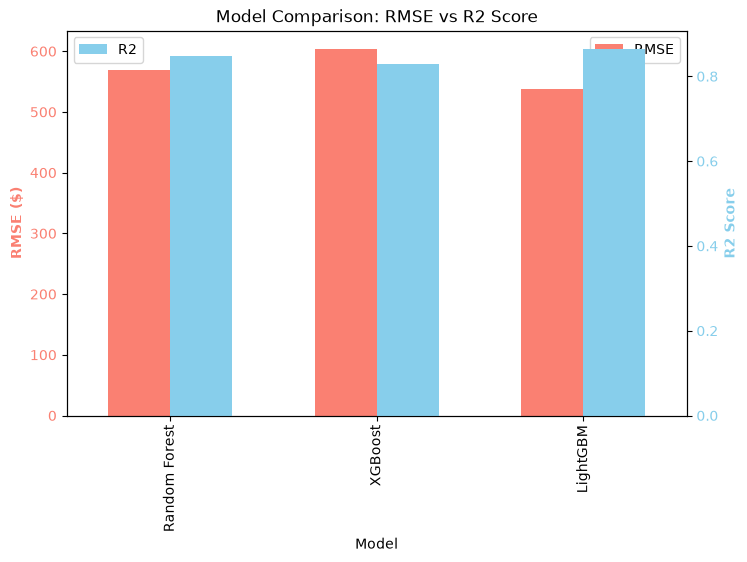

In [16]:
import matplotlib.pyplot as plt

# Format results into a DataFrame
results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

# Plotting RMSE and R2
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot for RMSE
results_df[['RMSE']].plot(kind='bar', ax=ax1, color='salmon', position=1, width=0.3)
ax1.set_ylabel('RMSE ($)', color='salmon', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='salmon')

# Second y-axis for R2
ax2 = ax1.twinx()
results_df[['R2']].plot(kind='bar', ax=ax2, color='skyblue', position=0, width=0.3)
ax2.set_ylabel('R2 Score', color='skyblue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='skyblue')

plt.title("Model Comparison: RMSE vs R2 Score")
plt.xlim(-0.5, 2.5)
plt.show()

# Second Experiment

In [17]:
import pandas as pd
import numpy as np

# 1. Load data
data = pd.read_csv("./dataset/train-test.csv")
data = data.drop(columns=['load_id'])

# 2. Haversine distance
def haversine_array(lat1, lon1, lat2, lon2):
    R = 3959.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

data['haversine_dist'] = haversine_array(data['pickup_lat'], data['pickup_lon'], 
                                         data['delivery_lat'], data['delivery_lon'])

# 3. Time features
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.dayofweek

# 4. EXPLICIT INTERACTION FEATURES (The game changers)
data['expected_base_rate'] = data['distance'] * data['quote_signal']
data['market_pressure'] = data['market_index'] * data['quote_signal']

data = data.drop(columns=['date', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon'])

In [18]:
from sklearn.model_selection import train_test_split

# Split first
X = data.drop(columns=['posted_rate'])
y = data['posted_rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Target Encoding for locations (using training data only)
for col in ['pickup', 'delivery']:
    city_means = y_train.groupby(X_train[col]).mean()
    X_train[col + '_encoded'] = X_train[col].map(city_means)
    # Fill unseen test cities with the overall global mean
    X_test[col + '_encoded'] = X_test[col].map(city_means).fillna(y_train.mean())

X_train = X_train.drop(columns=['pickup', 'delivery'])
X_test = X_test.drop(columns=['pickup', 'delivery'])

# Keep equipment as one-hot since it has very few categories
X_train = pd.get_dummies(X_train, columns=['equipment'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['equipment'], drop_first=True)

# Ensure columns match after encoding
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import time

# Transform target to compress outliers
y_train_log = np.log1p(y_train)

def evaluate_log_model(name, model, X_t, y_t_raw, fit_time):
    # Predict on log scale, then inverse transform back to normal dollars
    log_preds = model.predict(X_t)
    real_preds = np.expm1(log_preds) 
    
    mae = mean_absolute_error(y_t_raw, real_preds)
    rmse = root_mean_squared_error(y_t_raw, real_preds)
    r2 = r2_score(y_t_raw, real_preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "Time (s)": fit_time}

results = []
models = {
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=42, n_jobs=-1)
}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train_log)
    fit_time = time.time() - start
    results.append(evaluate_log_model(name, model, X_test, y_test, fit_time))
    print(f"{name} done.")

Random Forest done.
XGBoost done.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1937
[LightGBM] [Info] Number of data points in the train set: 38400, number of used features: 13
[LightGBM] [Info] Start training from score 7.571839
LightGBM done.


,MAE,RMSE,R2,Time (s)
Model,,,,
Random Forest,114.682138,540.587955,0.863354,8.044988
XGBoost,122.044459,540.132636,0.863584,0.566030
LightGBM,99.722891,529.702860,0.868802,0.463746


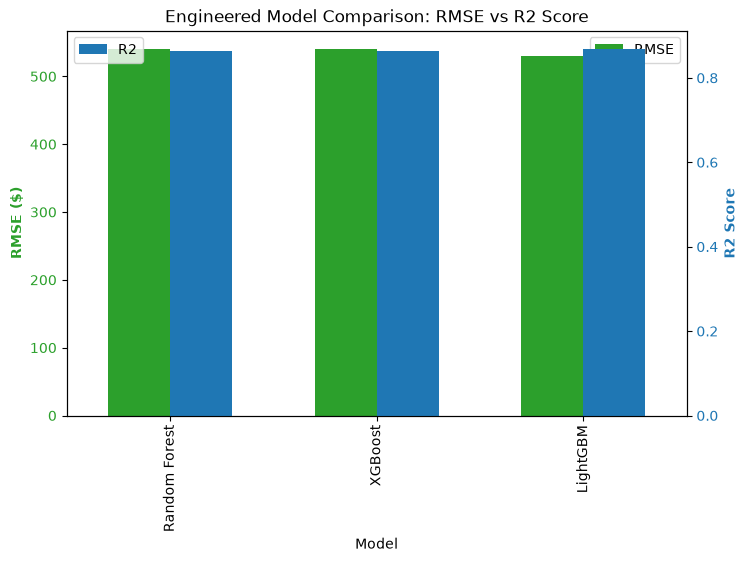

In [20]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

fig, ax1 = plt.subplots(figsize=(8, 5))

results_df[['RMSE']].plot(kind='bar', ax=ax1, color='#2ca02c', position=1, width=0.3)
ax1.set_ylabel('RMSE ($)', color='#2ca02c', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2ca02c')

ax2 = ax1.twinx()
results_df[['R2']].plot(kind='bar', ax=ax2, color='#1f77b4', position=0, width=0.3)
ax2.set_ylabel('R2 Score', color='#1f77b4', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#1f77b4')

plt.title("Engineered Model Comparison: RMSE vs R2 Score")
plt.xlim(-0.5, 2.5)
plt.show()

# Third Experiment

In [24]:
import pandas as pd
import numpy as np

data = pd.read_csv("./dataset/train-test.csv").drop(columns=['load_id'])

# 1. Cull the extreme 1% outliers dragging down RMSE
threshold = data['posted_rate'].quantile(0.99)
data = data[data['posted_rate'] <= threshold].copy()

# 2. Add engineered math features
def haversine(lat1, lon1, lat2, lon2):
    R = 3959.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

data['haversine_dist'] = haversine(data['pickup_lat'], data['pickup_lon'], 
                                   data['delivery_lat'], data['delivery_lon'])
data['expected_base_rate'] = data['distance'] * data['quote_signal']
data['market_pressure'] = data['market_index'] * data['quote_signal']

# 3. Set native category types for advanced tree models
categorical_cols = ['pickup', 'delivery', 'equipment']
data[categorical_cols] = data[categorical_cols].astype('category')

# Drop unused columns
data = data.drop(columns=['date', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon'])

In [26]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['posted_rate'])
y = data['posted_rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a numeric-only copy specifically for Random Forest
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

overall_mean = y_train.mean()

for col in ['pickup', 'delivery', 'equipment']:
    means = y_train.groupby(X_train_rf[col], observed=False).mean()
    X_train_rf[col] = X_train_rf[col].astype(object).map(means).astype(float)
    X_test_rf[col] = X_test_rf[col].astype(object).map(means).fillna(overall_mean).astype(float)

In [27]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import time

y_train_log = np.log1p(y_train)

def eval_model(name, model, X_train_data, X_test_data):
    start = time.time()
    model.fit(X_train_data, y_train_log)
    fit_time = time.time() - start
    
    preds = np.expm1(model.predict(X_test_data))
    
    return {"Model": name, 
            "MAE": mean_absolute_error(y_test, preds), 
            "RMSE": root_mean_squared_error(y_test, preds), 
            "R2": r2_score(y_test, preds), 
            "Time (s)": fit_time}

models = [
    ("Random Forest", RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1), X_train_rf, X_test_rf),
    ("XGBoost", xgb.XGBRegressor(enable_categorical=True, learning_rate=0.05, n_estimators=500, max_depth=6, random_state=42, n_jobs=-1), X_train, X_test),
    ("LightGBM", lgb.LGBMRegressor(learning_rate=0.05, n_estimators=500, num_leaves=31, random_state=42, n_jobs=-1), X_train, X_test)
]

results = [eval_model(name, mdl, xtr, xte) for name, mdl, xtr, xte in models]
print("Tuned training complete.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1917
[LightGBM] [Info] Number of data points in the train set: 38016, number of used features: 10
[LightGBM] [Info] Start training from score 7.557975
Tuned training complete.


,MAE,RMSE,R2,Time (s)
Model,,,,
Random Forest,78.593825,248.200403,0.965574,11.627909
XGBoost,87.299174,247.729603,0.965704,5.609055
LightGBM,84.479508,242.214084,0.967215,2.414263


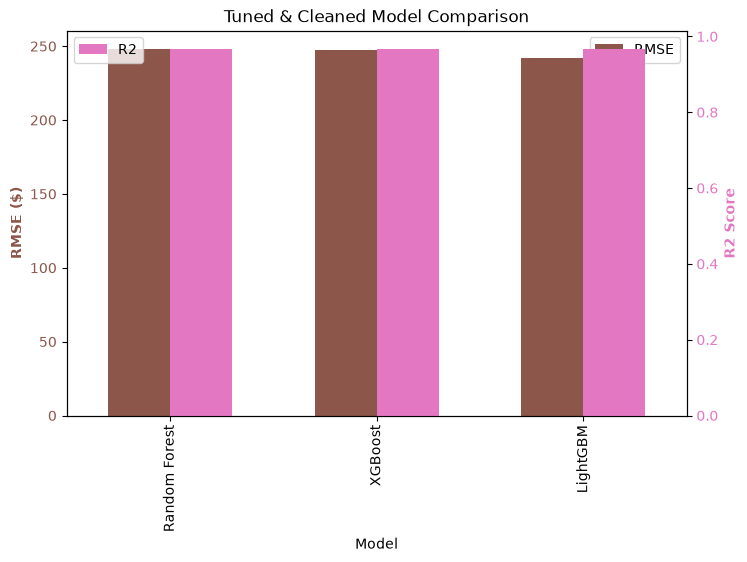

In [28]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

fig, ax1 = plt.subplots(figsize=(8, 5))

results_df[['RMSE']].plot(kind='bar', ax=ax1, color='#8c564b', position=1, width=0.3)
ax1.set_ylabel('RMSE ($)', color='#8c564b', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#8c564b')

ax2 = ax1.twinx()
results_df[['R2']].plot(kind='bar', ax=ax2, color='#e377c2', position=0, width=0.3)
ax2.set_ylabel('R2 Score', color='#e377c2', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#e377c2')

plt.title("Tuned & Cleaned Model Comparison")
plt.xlim(-0.5, 2.5)
plt.show()